# Marketing Campaign Performance Analysis

**Goal:** Identify the highest-performing channels, campaign types, and audience segments by ROI,
conversion rate, and engagement -- then add a predictive layer to test whether campaign performance
can be predicted from its attributes (channel, audience, duration, cost), going beyond plain BI metrics.

**Data:** [Marketing Campaign Performance Dataset](https://www.kaggle.com/datasets/manishabhatt22/marketing-campaign-performance-dataset)
(Kaggle, manishabhatt22) -- ~200,000 rows spanning 2 years of campaign-level records.


In [8]:
# --- Imports ---
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

sns.set_style("whitegrid")


## 1. Load the data

In [9]:
import kagglehub

path = kagglehub.dataset_download("manishabhatt22/marketing-campaign-performance-dataset")
print("Path to dataset files:", path)

import os
print(os.listdir(path))


Using Colab cache for faster access to the 'marketing-campaign-performance-dataset' dataset.
Path to dataset files: /kaggle/input/marketing-campaign-performance-dataset
['.nfs0000000049f0392000000004', 'marketing_campaign_dataset.csv']


In [10]:
df = pd.read_csv(f"{path}/marketing_campaign_dataset.csv")  # adjust filename if os.listdir() showed something different

print(df.shape)
print(df.columns.tolist())
df.head(10)


(200000, 16)
['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date']


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05
5,6,DataTech Solutions,Display,All Ages,15 days,Instagram,0.07,"$9,716.00",4.36,New York,German,100,1643,1,Foodies,2021-01-06
6,7,NexGen Systems,Email,Women 35-44,60 days,Website,0.13,"$11,067.00",2.86,Los Angeles,Spanish,817,8749,10,Tech Enthusiasts,2021-01-07
7,8,DataTech Solutions,Search,Men 18-24,45 days,Google Ads,0.08,"$13,280.00",5.55,Los Angeles,Mandarin,624,7854,7,Outdoor Adventurers,2021-01-08
8,9,Alpha Innovations,Social Media,Women 35-44,15 days,Facebook,0.09,"$18,066.00",6.73,Chicago,German,861,1754,6,Tech Enthusiasts,2021-01-09
9,10,TechCorp,Email,Women 35-44,15 days,Instagram,0.09,"$13,766.00",3.78,Los Angeles,English,642,3856,3,Tech Enthusiasts,2021-01-10


## 2. Clean and engineer features



In [11]:

if df["Acquisition_Cost"].dtype == object:
    df["Acquisition_Cost"] = (
        df["Acquisition_Cost"].astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )


print(df[["Conversion_Rate", "ROI", "Acquisition_Cost", "Clicks", "Impressions"]].describe())

# Click-through rate, computed directly (not provided as a raw column)
df["CTR"] = df["Clicks"] / df["Impressions"]

df.isna().sum().sort_values(ascending=False).head(10)


       Conversion_Rate            ROI  Acquisition_Cost         Clicks  \
count    200000.000000  200000.000000     200000.000000  200000.000000   
mean          0.080070       5.002438      12504.393040     549.772030   
std           0.040602       1.734488       4337.664545     260.019056   
min           0.010000       2.000000       5000.000000     100.000000   
25%           0.050000       3.500000       8739.750000     325.000000   
50%           0.080000       5.010000      12496.500000     550.000000   
75%           0.120000       6.510000      16264.000000     775.000000   
max           0.150000       8.000000      20000.000000    1000.000000   

         Impressions  
count  200000.000000  
mean     5507.301520  
std      2596.864286  
min      1000.000000  
25%      3266.000000  
50%      5517.500000  
75%      7753.000000  
max     10000.000000  


,0
Campaign_ID,0
Company,0
Campaign_Type,0
Target_Audience,0
Duration,0
Channel_Used,0
Conversion_Rate,0
Acquisition_Cost,0
ROI,0
Location,0


## 3. SQL-based breakdown (sqlite3 in-notebook)

In [12]:
conn = sqlite3.connect(":memory:")
df.to_sql("campaigns", conn, index=False, if_exists="replace")

by_campaign_type = pd.read_sql_query('''
    SELECT Campaign_Type,
           COUNT(*) AS n_campaigns,
           ROUND(AVG(Conversion_Rate), 4) AS avg_conversion_rate,
           ROUND(AVG(ROI), 4) AS avg_roi,
           ROUND(AVG(Engagement_Score), 2) AS avg_engagement,
           ROUND(AVG(CTR), 4) AS avg_ctr
    FROM campaigns
    GROUP BY Campaign_Type
    ORDER BY avg_roi DESC
''', conn)

by_campaign_type


,Campaign_Type,n_campaigns,avg_conversion_rate,avg_roi,avg_engagement,avg_ctr
0,Influencer,40169,0.0803,5.0111,5.48,0.1403
1,Search,40157,0.0800,5.0084,5.49,0.1399
2,Display,39987,0.0801,5.0066,5.51,0.1413
3,Email,39870,0.0798,4.9943,5.50,0.1395
4,Social Media,39817,0.0801,4.9918,5.50,0.1410


In [13]:
by_channel = pd.read_sql_query('''
    SELECT Channel_Used,
           COUNT(*) AS n_campaigns,
           ROUND(AVG(Conversion_Rate), 4) AS avg_conversion_rate,
           ROUND(AVG(ROI), 4) AS avg_roi,
           ROUND(AVG(Acquisition_Cost), 2) AS avg_acquisition_cost
    FROM campaigns
    GROUP BY Channel_Used
    ORDER BY avg_roi DESC
''', conn)

by_channel

,Channel_Used,n_campaigns,avg_conversion_rate,avg_roi,avg_acquisition_cost
0,Facebook,32819,0.0800,5.0187,12510.90
1,Website,33360,0.0802,5.0142,12487.81
2,Google Ads,33438,0.0802,5.0031,12528.03
3,Email,33599,0.0803,4.9965,12526.39
4,YouTube,33392,0.0799,4.9938,12481.39
5,Instagram,33392,0.0799,4.9887,12491.76


In [14]:
by_segment = pd.read_sql_query('''
    SELECT Customer_Segment,
           COUNT(*) AS n_campaigns,
           ROUND(AVG(Conversion_Rate), 4) AS avg_conversion_rate,
           ROUND(AVG(ROI), 4) AS avg_roi,
           ROUND(AVG(Engagement_Score), 2) AS avg_engagement
    FROM campaigns
    GROUP BY Customer_Segment
    ORDER BY avg_roi DESC
''', conn)

by_segment


,Customer_Segment,n_campaigns,avg_conversion_rate,avg_roi,avg_engagement
0,Foodies,40208,0.0803,5.0044,5.51
1,Tech Enthusiasts,40151,0.0802,5.0042,5.49
2,Health & Wellness,39888,0.0799,5.0032,5.48
3,Fashionistas,39742,0.0798,5.0010,5.49
4,Outdoor Adventurers,40011,0.0802,4.9994,5.50


In [15]:
by_audience = pd.read_sql_query('''
    SELECT Target_Audience,
           COUNT(*) AS n_campaigns,
           ROUND(AVG(Conversion_Rate), 4) AS avg_conversion_rate,
           ROUND(AVG(ROI), 4) AS avg_roi
    FROM campaigns
    GROUP BY Target_Audience
    ORDER BY avg_roi DESC
''', conn)

by_audience


,Target_Audience,n_campaigns,avg_conversion_rate,avg_roi
0,Men 25-34,40023,0.0801,5.0206
1,Women 35-44,39687,0.0801,5.0063
2,All Ages,40019,0.0800,5.0052
3,Women 25-34,40013,0.0799,4.9974
4,Men 18-24,40258,0.0802,4.9829


## 4. Export tables for Tableau Public

In [17]:
by_campaign_type.to_csv("roi_by_campaign_type.csv", index=False)
by_channel.to_csv("roi_by_channel.csv", index=False)
by_segment.to_csv("roi_by_segment.csv", index=False)
by_audience.to_csv("roi_by_audience.csv", index=False)


## 5. Predictive layer: can campaign attributes predict ROI?

Train a regression model on campaign-level attributes (channel, audience, duration, cost) to predict ROI,
and compare against a naive baseline (always predicting the average ROI). Given the expectation-setting
note in the intro, don't be surprised if this model barely beats the baseline - that itself is a valid,
reportable finding about how much real structure this dataset contains.


In [19]:
features = ["Campaign_Type", "Channel_Used", "Target_Audience", "Customer_Segment", "Duration", "Acquisition_Cost"]
target = "ROI"

model_df = df[features + [target]].dropna()
X = pd.get_dummies(model_df[features], drop_first=True)
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline: always predict the mean ROI from the training set
baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

print("Baseline MAE (always predict mean ROI):", round(baseline_mae, 4))
print("Model R²:", round(r2_score(y_test, preds), 4))
print("Model MAE:", round(mean_absolute_error(y_test, preds), 4))

Baseline MAE (always predict mean ROI): 1.5027
Model R²: -0.0865
Model MAE: 1.5452


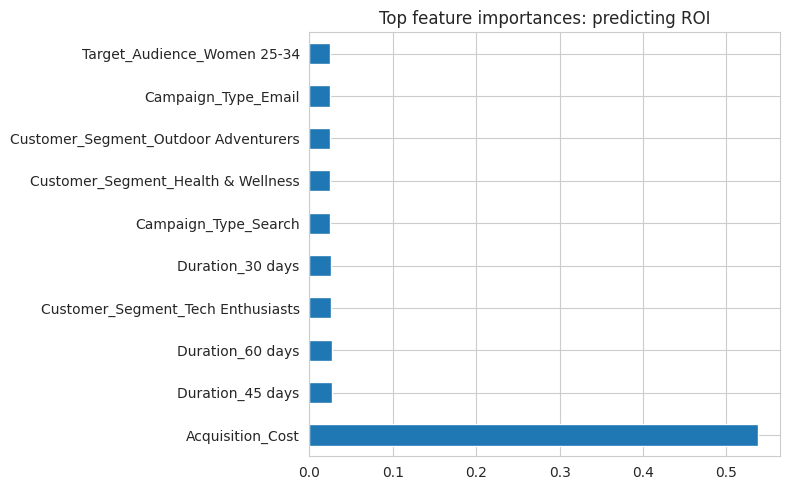

In [20]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10).plot(kind="barh", figsize=(8,5))
plt.title("Top feature importances: predicting ROI")
plt.tight_layout()
plt.show()


## 6. Conclusions

# Marketing Campaign Performance Analysis - Conclusions

**Breakdown by Category:** All four breakdowns (campaign type, channel, customer segment, and target audience) are essentially flat. Conversion rate sits at ~0.080 across every category (range 0.0798-0.0803), and ROI sits at ~5.00 across every category (range 4.9829-5.0206). There is no meaningful "winning" campaign type, channel, segment, or audience in this dataset. Every category performs within noise of every other. This confirms the expectation flagged earlier: this synthetic dataset generates metrics from what looks like a fixed distribution with random noise layered on top, not real structural differences between segments.

**Predictive Model (the key finding):** The Random Forest model achieved a **negative R² (-0.0865)**, and its MAE (1.5452) was actually *worse* than simply predicting the mean ROI for every campaign (baseline MAE: 1.5027). A negative R² means the model performs worse than a flat-line guess, which is strong, direct evidence that there is no learnable relationship between campaign attributes (type, channel, audience, segment, duration, cost) and ROI in this dataset.

**Why the feature importance chart is misleading on its own:** the chart shows `Acquisition_Cost` contributing ~54% of total importance, far above any categorical feature, which looks like "acquisition cost predicts ROI." It doesn't, given the negative R² above. Random Forest's default importance metric is biased toward continuous, high-cardinality features (`Acquisition_Cost` has thousands of unique values) over one-hot-encoded categorical dummies (mostly 0s and 1s); it will rank such features as "important" even when the model has no real predictive power overall. **No feature importance in this chart should be read as a real relationship**, because the model has no genuine pattern to explain in the first place.

**Takeaway:** This dataset shows no detectable relationship between campaign attributes and performance outcomes. That's a legitimate, clearly-evidenced finding. Catching both the flat breakdowns and the negative R² (rather than stopping at the feature-importance chart and overinterpreting it) is a stronger demonstration of statistical judgment than a flashier, less accurate story would have been.

**Other Limitations:**
- Dataset is synthetic, so these findings describe patterns in generated data, not real market behavior.
- Campaign-level granularity (not individual-customer-level) limits how specific any conversion analysis can get.
- No date/seasonality analysis was included despite the data spanning 2 years. Given how flat every other breakdown was, though, a seasonal effect would be a surprising find here too.
